# 04 - Experimentacion de Modelado y Ensambles

Objetivo: comparar modelos base, ensambles y boostings usando splits temporales creados en Snowflake.

Reglas:
- Train: 2015-2023.
- Validacion: 2024.
- Test: 2025, solo para el modelo ganador.
- No usar columnas con leakage.
- No descargar la base completa; se usan muestras representativas y reproducibles.


## 1) Setup, conexion y dependencias


In [1]:
from pathlib import Path
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import snowflake.connector

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.config import get_project_config

cfg = get_project_config(required=True)
train_table = cfg.fq_table(cfg.train_table)
val_table = cfg.fq_table(cfg.val_table)
test_table = cfg.fq_table(cfg.test_table)
target = cfg.target_column

print("TRAIN:", train_table)
print("VAL:", val_table)
print("TEST:", test_table)
print("MODEL_PATH:", cfg.model_path)


TRAIN: ANALYTICS.TRAIN_SET
VAL: ANALYTICS.VAL_SET
TEST: ANALYTICS.TEST_SET
MODEL_PATH: F:\Data mining\Proyecto Final\data\processed\price_model.pkl


In [2]:
def get_connection():
    return snowflake.connector.connect(**cfg.snowflake.connector_kwargs)


def query_df(sql: str) -> pd.DataFrame:
    with get_connection() as conn:
        with conn.cursor() as cur:
            cur.execute(sql)
            return cur.fetch_pandas_all()


## 2) Features y muestras temporales

La muestra de entrenamiento se toma solo de `TRAIN_SET`; la de validacion solo de `VAL_SET`. Los parametros se pueden subir si la maquina tiene memoria suficiente.


In [3]:
NUMERIC_FEATURES = [
    "TRIP_DISTANCE",
    "PASSENGER_COUNT",
    "PICKUP_HOUR",
    "DAY_OF_WEEK",
    "MONTH",
    "YEAR",
    "IS_WEEKEND",
    "SAME_BOROUGH_FLAG",
    "AIRPORT_TRIP_FLAG",
]

LOW_CARDINALITY_CATEGORICAL_FEATURES = [
    "SERVICE_TYPE",
    "VENDOR_ID",
    "RATE_CODE_ID",
    "TRIP_TYPE",
    "PICKUP_TIME_BAND",
    "PU_BOROUGH",
    "DO_BOROUGH",
]

HIGH_CARDINALITY_BASE_FEATURES = [
    "PU_LOCATION_ID",
    "DO_LOCATION_ID",
    "LOCATION_PAIR",
]

MODEL_FEATURES = NUMERIC_FEATURES + LOW_CARDINALITY_CATEGORICAL_FEATURES + HIGH_CARDINALITY_BASE_FEATURES
select_cols = ", ".join(MODEL_FEATURES + [target])

TOP_N_LOCATION_PAIRS = 300
TRAIN_SAMPLE_PCT = 0.004
VAL_SAMPLE_PCT = 0.02
TEST_SAMPLE_PCT = 0.02
TRAIN_LIMIT = 50_000
VAL_LIMIT = 15_000
TEST_LIMIT = 15_000

print("features:", len(MODEL_FEATURES))


features: 19


In [4]:
split_summary_df = query_df(f"""
SELECT 'TRAIN' AS split_name, COUNT(*) AS rows_split, MIN(YEAR) AS min_year, MAX(YEAR) AS max_year FROM {train_table}
UNION ALL SELECT 'VAL', COUNT(*), MIN(YEAR), MAX(YEAR) FROM {val_table}
UNION ALL SELECT 'TEST', COUNT(*), MIN(YEAR), MAX(YEAR) FROM {test_table}
ORDER BY split_name
""")
split_summary_df


,SPLIT_NAME,ROWS_SPLIT,MIN_YEAR,MAX_YEAR
0,TEST,44109224,2025,2025
1,TRAIN,760168027,2015,2023
2,VAL,39723735,2024,2024


In [5]:
location_pair_top_df = query_df(f"""
SELECT LOCATION_PAIR, COUNT(*) AS rows_total
FROM {train_table}
GROUP BY 1
ORDER BY rows_total DESC
LIMIT {TOP_N_LOCATION_PAIRS}
""")
TOP_LOCATION_PAIRS = set(location_pair_top_df["LOCATION_PAIR"].astype(str))
location_pair_top_df.head(10)


,LOCATION_PAIR,ROWS_TOTAL
0,264_264,6985111
1,237_236,3957112
2,236_237,3380152
3,236_236,3082317
4,237_237,2928078
5,239_238,1808784
6,239_142,1790265
7,237_162,1717992
8,142_239,1701715
9,237_161,1696797


In [6]:
train_df = query_df(f"""
SELECT {select_cols}
FROM {train_table} SAMPLE BERNOULLI ({TRAIN_SAMPLE_PCT})
LIMIT {TRAIN_LIMIT}
""")

val_df = query_df(f"""
SELECT {select_cols}
FROM {val_table} SAMPLE BERNOULLI ({VAL_SAMPLE_PCT})
LIMIT {VAL_LIMIT}
""")

print("train:", train_df.shape)
print("val:", val_df.shape)
train_df.head()


train: (30436, 20)
val: (7911, 20)


,TRIP_DISTANCE,PASSENGER_COUNT,PICKUP_HOUR,DAY_OF_WEEK,MONTH,YEAR,IS_WEEKEND,SAME_BOROUGH_FLAG,AIRPORT_TRIP_FLAG,SERVICE_TYPE,VENDOR_ID,RATE_CODE_ID,TRIP_TYPE,PICKUP_TIME_BAND,PU_BOROUGH,DO_BOROUGH,PU_LOCATION_ID,DO_LOCATION_ID,LOCATION_PAIR,TOTAL_AMOUNT
0,2.9800,1.0000,12,5,12,2017,0,1,0,green,2,1.0000,1.0000,midday,Brooklyn,Brooklyn,62,62,62_62,14.3000
1,2.3500,1.0000,11,3,12,2017,0,1,0,green,2,1.0000,1.0000,midday,Manhattan,Manhattan,166,143,166_143,11.3000
2,0.5700,1.0000,10,4,12,2017,0,1,0,green,2,1.0000,1.0000,midday,Bronx,Bronx,159,167,159_167,5.8000
3,7.9100,1.0000,22,7,12,2017,1,0,0,green,2,1.0000,1.0000,night,Brooklyn,Manhattan,181,140,181_140,35.7600
4,2.2700,4.0000,15,5,12,2017,0,1,0,green,2,1.0000,1.0000,midday,Manhattan,Manhattan,166,42,166_42,14.7600


## 3) Preprocesamiento reutilizable


In [7]:
class TripFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, top_location_pairs=None):
        self.top_location_pairs = set(top_location_pairs or [])

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        out = X.copy()
        categorical_cols = LOW_CARDINALITY_CATEGORICAL_FEATURES + HIGH_CARDINALITY_BASE_FEATURES
        for col in categorical_cols:
            out[col] = out[col].astype("string").fillna("Unknown")
        out["LOCATION_PAIR_TOP"] = np.where(
            out["LOCATION_PAIR"].isin(self.top_location_pairs),
            out["LOCATION_PAIR"],
            "OTHER",
        )
        return out.drop(columns=["LOCATION_PAIR"])


ENGINEERED_NUMERIC_FEATURES = NUMERIC_FEATURES
ENGINEERED_CATEGORICAL_FEATURES = LOW_CARDINALITY_CATEGORICAL_FEATURES + [
    "PU_LOCATION_ID", "DO_LOCATION_ID", "LOCATION_PAIR_TOP"
]
ENGINEERED_FEATURES = ENGINEERED_NUMERIC_FEATURES + ENGINEERED_CATEGORICAL_FEATURES


def make_preprocessor():
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50, sparse_output=True)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, ENGINEERED_NUMERIC_FEATURES),
            ("cat", categorical_pipeline, ENGINEERED_CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )


def make_pipeline(model):
    return Pipeline(steps=[
        ("feature_engineering", TripFeatureEngineer(TOP_LOCATION_PAIRS)),
        ("preprocessor", make_preprocessor()),
        ("model", model),
    ])

X_train = train_df[MODEL_FEATURES]
y_train = train_df[target]
X_val = val_df[MODEL_FEATURES]
y_val = val_df[target]

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)


(30436, 19) (30436,) (7911, 19) (7911,)


In [8]:
# Smoke test del preprocesador antes de entrenar modelos.
preprocess_smoke = Pipeline(steps=[
    ("feature_engineering", TripFeatureEngineer(TOP_LOCATION_PAIRS)),
    ("preprocessor", make_preprocessor()),
])
X_train_transformed = preprocess_smoke.fit_transform(X_train)
X_val_transformed = preprocess_smoke.transform(X_val)
print("train transformed:", X_train_transformed.shape)
print("val transformed:", X_val_transformed.shape)
assert X_train_transformed.shape[1] == X_val_transformed.shape[1]


train transformed: (30436, 248)
val transformed: (7911, 248)


## 4) Modelos a comparar

Incluye baseline, Voting, Bagging, Pasting y los boostings obligatorios: AdaBoost, GradientBoosting, XGBoost, LightGBM y CatBoost.


In [9]:
RANDOM_STATE = cfg.random_state

models = {
    "baseline_ridge": Ridge(alpha=1.0),
    "random_forest": RandomForestRegressor(
        n_estimators=80, max_depth=16, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "extra_trees": ExtraTreesRegressor(
        n_estimators=80, max_depth=18, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "voting_rf_et_ridge": VotingRegressor(
        estimators=[
            ("rf", RandomForestRegressor(n_estimators=50, max_depth=14, min_samples_leaf=25, n_jobs=-1, random_state=RANDOM_STATE)),
            ("et", ExtraTreesRegressor(n_estimators=50, max_depth=16, min_samples_leaf=25, n_jobs=-1, random_state=RANDOM_STATE)),
            ("ridge", Ridge(alpha=1.0)),
        ],
        n_jobs=-1,
    ),
    "bagging_tree": BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=16, min_samples_leaf=25, random_state=RANDOM_STATE),
        n_estimators=60,
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "pasting_tree": BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=16, min_samples_leaf=25, random_state=RANDOM_STATE),
        n_estimators=60,
        bootstrap=False,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "adaboost": AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=8, min_samples_leaf=30, random_state=RANDOM_STATE),
        n_estimators=80,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    ),
    "gradient_boosting": GradientBoostingRegressor(
        n_estimators=160,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=RANDOM_STATE,
    ),
    "xgboost": XGBRegressor(
        n_estimators=220,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "lightgbm": LGBMRegressor(
        n_estimators=260,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    "catboost": CatBoostRegressor(
        iterations=220,
        learning_rate=0.05,
        depth=7,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    ),
}

list(models.keys())


['baseline_ridge',
 'random_forest',
 'extra_trees',
 'voting_rf_et_ridge',
 'bagging_tree',
 'pasting_tree',
 'adaboost',
 'gradient_boosting',
 'xgboost',
 'lightgbm',
 'catboost']

## 5) Entrenamiento y validacion


In [10]:
def regression_metrics(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


results = []
fitted_pipelines = {}

for name, estimator in models.items():
    print(f"\nEntrenando {name}...")
    started = time.perf_counter()
    pipeline = make_pipeline(clone(estimator))
    pipeline.fit(X_train, y_train)
    train_pred = pipeline.predict(X_train)
    val_pred = pipeline.predict(X_val)
    elapsed = time.perf_counter() - started

    train_rmse, train_mae, train_r2 = regression_metrics(y_train, train_pred)
    val_rmse, val_mae, val_r2 = regression_metrics(y_val, val_pred)

    results.append({
        "model": name,
        "train_rmse": train_rmse,
        "val_rmse": val_rmse,
        "train_mae": train_mae,
        "val_mae": val_mae,
        "train_r2": train_r2,
        "val_r2": val_r2,
        "fit_seconds": elapsed,
    })
    fitted_pipelines[name] = pipeline
    print(f"{name}: val_rmse={val_rmse:.4f}, val_mae={val_mae:.4f}, seconds={elapsed:.1f}")

results_df = pd.DataFrame(results).sort_values("val_rmse").reset_index(drop=True)
results_df


Entrenando baseline_ridge...
baseline_ridge: val_rmse=9.4022, val_mae=5.6353, seconds=0.4

Entrenando random_forest...
random_forest: val_rmse=7.8617, val_mae=4.4309, seconds=6.0

Entrenando extra_trees...
extra_trees: val_rmse=7.9146, val_mae=4.3425, seconds=6.9

Entrenando voting_rf_et_ridge...
voting_rf_et_ridge: val_rmse=7.7388, val_mae=4.4057, seconds=9.9

Entrenando bagging_tree...
bagging_tree: val_rmse=7.8915, val_mae=4.4447, seconds=11.5

Entrenando pasting_tree...
pasting_tree: val_rmse=8.0737, val_mae=4.6711, seconds=9.3

Entrenando adaboost...
adaboost: val_rmse=7.1761, val_mae=4.3044, seconds=16.3

Entrenando gradient_boosting...
gradient_boosting: val_rmse=6.3425, val_mae=3.9071, seconds=12.1

Entrenando xgboost...
xgboost: val_rmse=6.7379, val_mae=3.8419, seconds=1.0

Entrenando lightgbm...
lightgbm: val_rmse=6.5296, val_mae=3.7913, seconds=1.4

Entrenando catboost...
catboost: val_rmse=6.9917, val_mae=3.9310, seconds=1.5


,model,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,fit_seconds
0,gradient_boosting,3.1140,6.3425,2.0850,3.9071,0.9544,0.9143,12.0727
1,lightgbm,3.1658,6.5296,1.8588,3.7913,0.9529,0.9092,1.3863
2,xgboost,2.9545,6.7379,1.9816,3.8419,0.9590,0.9033,0.9551
3,catboost,3.3516,6.9917,2.1692,3.9310,0.9472,0.8958,1.4846
4,adaboost,3.7141,7.1761,2.4242,4.3044,0.9351,0.8903,16.2679
5,voting_rf_et_ridge,4.3713,7.7388,2.2591,4.4057,0.9102,0.8724,9.8850
6,random_forest,4.4944,7.8617,2.1845,4.4309,0.9050,0.8683,6.0145
7,bagging_tree,4.5858,7.8915,2.2334,4.4447,0.9011,0.8673,11.5004
8,extra_trees,4.5125,7.9146,2.2130,4.3425,0.9043,0.8665,6.8866
9,pasting_tree,4.6143,8.0737,2.2844,4.6711,0.8999,0.8611,9.2606


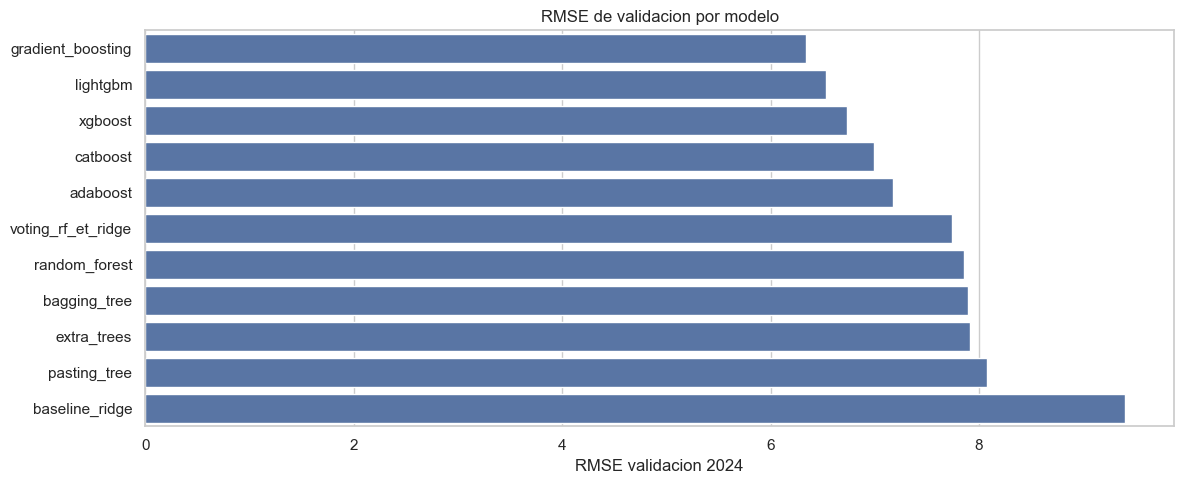

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=results_df, x="val_rmse", y="model", ax=ax)
ax.set_title("RMSE de validacion por modelo")
ax.set_xlabel("RMSE validacion 2024")
ax.set_ylabel("")
plt.tight_layout()


## 6) Diagnostico del mejor modelo en validacion


Mejor modelo: gradient_boosting
RMSE val: 6.342455874580352


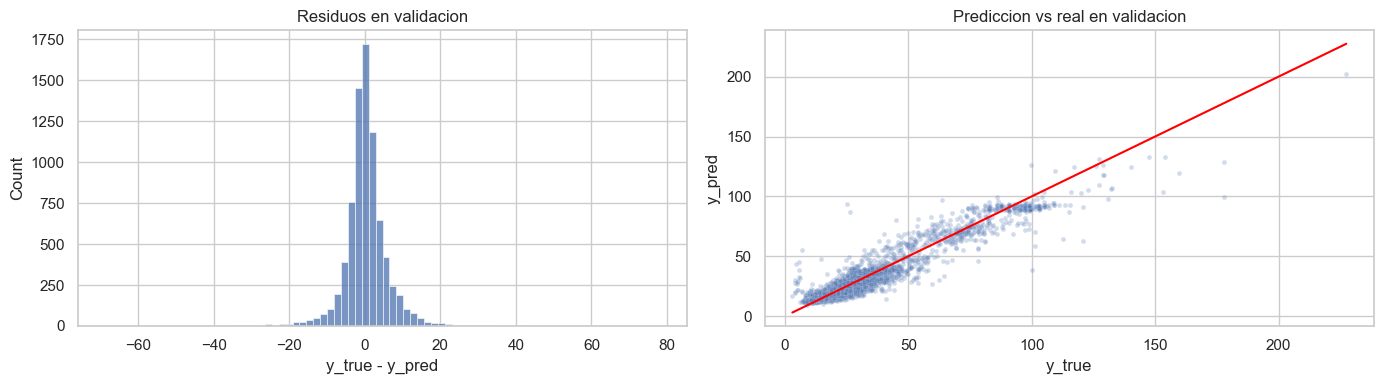

In [12]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = fitted_pipelines[best_model_name]
val_pred = best_pipeline.predict(X_val)
residuals = y_val - val_pred

print("Mejor modelo:", best_model_name)
print("RMSE val:", results_df.iloc[0]["val_rmse"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(residuals, bins=80, ax=axes[0])
axes[0].set_title("Residuos en validacion")
axes[0].set_xlabel("y_true - y_pred")

plot_df = pd.DataFrame({"y_true": y_val, "y_pred": val_pred}).sample(min(len(y_val), 5000), random_state=RANDOM_STATE)
sns.scatterplot(data=plot_df, x="y_true", y="y_pred", alpha=0.25, s=12, ax=axes[1])
axes[1].plot([plot_df.y_true.min(), plot_df.y_true.max()], [plot_df.y_true.min(), plot_df.y_true.max()], color="red")
axes[1].set_title("Prediccion vs real en validacion")
plt.tight_layout()


## 7) Evaluacion final en TEST solo con el ganador

Esta evaluacion usa una muestra de `TEST_SET` por costo computacional. Para el reporte final, se puede aumentar `TEST_LIMIT` o evaluar por batches.


In [13]:
test_df = query_df(f"""
SELECT {select_cols}
FROM {test_table} SAMPLE BERNOULLI ({TEST_SAMPLE_PCT})
LIMIT {TEST_LIMIT}
""")

X_test = test_df[MODEL_FEATURES]
y_test = test_df[target]
test_pred = best_pipeline.predict(X_test)
test_rmse, test_mae, test_r2 = regression_metrics(y_test, test_pred)

test_metrics_df = pd.DataFrame([{
    "model": best_model_name,
    "test_rows": len(test_df),
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_r2": test_r2,
}])
test_metrics_df


,model,test_rows,test_rmse,test_mae,test_r2
0,gradient_boosting,8883,7.9258,4.8191,0.8503


## 8) Exportacion del modelo ganador


In [14]:
cfg.model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "model_name": best_model_name,
    "pipeline": best_pipeline,
    "model_features": MODEL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": LOW_CARDINALITY_CATEGORICAL_FEATURES,
    "top_location_pairs": sorted(TOP_LOCATION_PAIRS),
    "validation_results": results_df,
    "test_metrics": test_metrics_df,
}, cfg.model_path)

print("Modelo exportado en:", cfg.model_path)


Modelo exportado en: F:\Data mining\Proyecto Final\data\processed\price_model.pkl


## 9) Conclusiones para produccion

- El modelo ganador se eligio con `VAL_SET` 2024.
- `TEST_SET` 2025 se uso solo despues de seleccionar ganador.
- Para productivizar, hay que migrar `TripFeatureEngineer`, `make_preprocessor` y las listas de features a `src/features/build_features.py`.
- Para entrenamiento final, se recomienda aumentar muestra o entrenar por batches desde `src/models/train_model.py`.
- El archivo exportado en `data/processed/price_model.pkl` es suficiente para conectar una primera API, pero todavia conviene refactorizarlo a `src/` antes de la entrega.
